TODO:
1. coitem algo
2. decouple candidates and target items
3. add regularization
4. update target items and candidates
5. lazy algo version


In [1]:
import numpy as np
from matplotlib import pyplot as plt


### Option 1. Item Gram matrix orthogonalization

Time: $ O(n_i^2 (n_q + k)) $

Additional space: $O(n_i ^ 2)$

In [2]:
def item_gram_matrix_orthogonalization(n_items, train, min_item_rel_norm=1e-5):
    item_gram_matrix = train.dot(train.T)
    mean_squared_norm = item_gram_matrix.diagonal().mean()
    min_item_norm = min_item_rel_norm * np.sqrt(mean_squared_norm) # rewrite through gram diag
    item_gram_matrix /= mean_squared_norm # for better float operations precision
    items = []
    item_scores = []
    remaining_items = np.ones(train.shape[0], dtype="bool")
    for t in range(n_items):
        scores = (item_gram_matrix ** 2).sum(axis=1)
        remaining_items &= item_gram_matrix.diagonal() >= (min_item_norm ** 2)
        scores[remaining_items] /= item_gram_matrix[remaining_items, remaining_items]
        scores[~remaining_items] = 0
        assert max(scores) > 1e-9
        new_item = scores.argmax()
        assert remaining_items[new_item]
        coefs = item_gram_matrix[new_item] / np.sqrt(item_gram_matrix[new_item, new_item])
        item_gram_matrix -= coefs.reshape(-1, 1).dot(coefs.reshape(1, -1))
        assert np.allclose(
            item_gram_matrix[new_item],
            np.zeros_like(item_gram_matrix[new_item]), atol=1e-6
        )
        items.append(new_item)
        item_scores.append(
            scores[new_item] * mean_squared_norm /
            (train.shape[0] * train.shape[1])
        )
        remaining_items[new_item] = False
    return np.array(items, dtype=np.int64), np.array(item_scores)


### Option 2. Orthogonalization in query gram matrix eigenbasis

Time: $O(n_q (n_i n_q + n_q^2 + k n_i)$ or $O(n_i n_q^2)$ if $n_i > n_q$ and $n_q > k$

Additional space: $O(n_q (n_i + n_q))$

In [3]:
def l2norm(v):
    return np.sqrt(np.sum(v ** 2))

def orthogonalization_in_query_eig_basis(n_items, train, min_item_rel_norm=1e-5):
    items = []
    item_scores = []

    query_gram_matrix = train.T.dot(train)
    sum_squared_error = query_gram_matrix.diagonal().sum()
    min_item_norm = min_item_rel_norm * np.sqrt(sum_squared_error / train.shape[0])
    mean_query_squared_norm = sum_squared_error / train.shape[1]
    query_gram_matrix /= mean_query_squared_norm # for better float operations precision
    squared_singular_values, item_space_rotation = np.linalg.eigh(query_gram_matrix)
    
    transformed_items = train.dot(item_space_rotation)
    remaining_items = np.ones(train.shape[0], dtype="bool")
    for t in range(n_items):
        item_squared_norms = (transformed_items ** 2).sum(axis=1)
        remaining_items &= (item_squared_norms >= min_item_norm ** 2)
        scores = ((transformed_items ** 2) * squared_singular_values).sum(axis=1)
        scores[remaining_items] /= item_squared_norms[remaining_items]
        scores[~remaining_items] = 0
        chosen_item = np.argmax(scores)
        assert chosen_item not in items
        assert remaining_items[chosen_item]
        items.append(chosen_item)
        item_scores.append(
            scores[chosen_item] * mean_query_squared_norm /
            (train.shape[0] * train.shape[1])
        )
        remaining_items[chosen_item] = False

        transformed_items[chosen_item] /= np.sqrt(item_squared_norms[chosen_item])
        transformed_items -= (
            (transformed_items * transformed_items[chosen_item]).sum(axis=1, keepdims=True).dot(
                transformed_items[chosen_item].reshape((1, -1))
            )
        )
    return np.array(items, dtype=np.int64), np.array(item_scores)

### Dual items 


Let\
$n_q$ be a number of support queries\
$n_c$ -- number of candidate items from which we choose support vectors\
$n_t$ -- number of items on which we optimize mse of approximation of relevance to support queries.\
$k$ -- number of support items to chose

Time: $O(n_t n_q^2 + n_c n_q^2 + k n_c n_q)$ = $O((n_t + n_c) n_q^2)$ assuming that $k \leqslant n_q$

Additional space: $O(n_q (n_c\ + n_q))$

In [4]:
def coitem_algorithm(n_support, candidate_items, target_items, min_item_rel_norm=1e-5):
    support_items = []
    support_items_scores = []
    n_c, n_q = candidate_items.shape
    n_t = target_items.shape[0]

    candidate_item_squared_norms = (candidate_items ** 2).sum(axis=1)
    min_item_norm = min_item_rel_norm * np.sqrt(candidate_item_squared_norms.mean())
    
    candidate_coitems = candidate_items.dot(
        target_items.T.dot(target_items)
    )
    orthonormed_support_items = np.zeros((n_support, n_q))
    remaining_items = np.ones(candidate_items.shape[0], dtype="bool")
    for t in range(n_support):
        scores = (candidate_coitems * candidate_items).sum(axis=1)
        remaining_items &= (candidate_item_squared_norms >= min_item_norm ** 2)
        scores[remaining_items] /= candidate_item_squared_norms[remaining_items]
        scores[~remaining_items] = 0
        
        new_item_id = np.argmax(scores)
        assert remaining_items[new_item_id]
        support_items.append(new_item_id)
        support_items_scores.append(scores[new_item_id] / (n_t * n_q))
        remaining_items[new_item_id] = False
        
        new_item = candidate_items[new_item_id].copy()
        new_item -= orthonormed_support_items[:t].T.dot(
            orthonormed_support_items[:t].dot(new_item)
        )
        assert np.allclose((new_item ** 2).sum(), candidate_item_squared_norms[new_item_id], atol=1e-6)
        new_item /= np.sqrt((new_item ** 2).sum())
        orthonormed_support_items[t] = new_item
        new_coitem = candidate_coitems[new_item_id] / np.sqrt(candidate_item_squared_norms[new_item_id])
        
        coefs = (candidate_items * new_item).sum(axis=1)
        candidate_item_squared_norms -= coefs ** 2
        assert np.all(candidate_item_squared_norms[remaining_items] > -1e-6)
        
        candidate_coitems -= coefs.reshape((-1, 1)).dot(new_coitem.reshape((1, -1)))
        cocoefs = (candidate_coitems * new_item).sum(axis=1, keepdims=True)
        candidate_coitems -= cocoefs.dot(new_item.reshape((1, -1)))
    return np.array(support_items, dtype=np.int64), np.array(support_items_scores)

In [5]:
with open("collections_1000_items/train.npy", "rb") as fin:
    train_items = np.load(fin)
train_items = train_items[:,:500].copy()
item_means = train_items.mean(axis=1, keepdims=True)
train_items -= item_means
train_items_copy = train_items.copy()

In [6]:
n_items = 100

In [7]:
IGMO_items, IGMO_items_scores = item_gram_matrix_orthogonalization(n_items, train_items)

In [8]:
OiQEB_items, OiQEB_item_scores = orthogonalization_in_query_eig_basis(n_items, train_items)

In [9]:
random_items = np.random.choice(train_items.shape[0], n_items, replace=False)

In [10]:
C_items, C_item_scores = coitem_algorithm(n_items, train_items, train_items)

In [11]:
assert np.allclose(train_items, train_items_copy)

In [12]:
def eval_items(items, train):
    approx_train = train.dot(np.linalg.pinv(train[items]).dot(train[items]))
    train_mse = np.mean((train - approx_train) ** 2)
    return train_mse

def calc_item_scores(items, train):
    # stupid algo
    mses = [(train ** 2).mean()]
    for cnt in range(1, len(items) + 1):
        mses.append(eval_items(items[:cnt], train))
    scores = []
    for i in range(len(items)):
        scores.append(mses[i] - mses[i + 1])
    return scores


In [13]:
recalculated_IGMO_scores = calc_item_scores(IGMO_items, train_items)
recalculated_OiQEB_scores = calc_item_scores(OiQEB_items, train_items)
recalculated_C_scores = calc_item_scores(C_items, train_items)
random_scores = calc_item_scores(random_items, train_items)

In [14]:
assert np.allclose(recalculated_IGMO_scores, IGMO_items_scores, atol=1e-6)
assert np.allclose(recalculated_OiQEB_scores, OiQEB_item_scores, atol=1e-6)
assert np.allclose(recalculated_C_scores, C_item_scores, atol=1e-6)
assert np.allclose(IGMO_items_scores, C_item_scores, atol=1e-7)

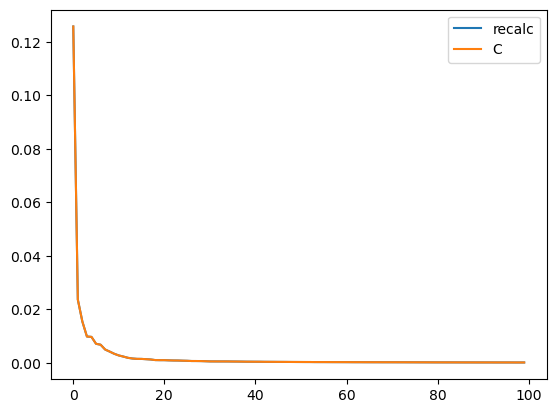

In [15]:
# assert np.allclose(recalculated_IGMO_scores, IGMO_items_scores, atol=1)
plt.plot(recalculated_C_scores, label="recalc")
plt.plot(C_item_scores, label="C")
plt.legend()
plt.show()

In [16]:
total_mse = np.mean(train_items ** 2)

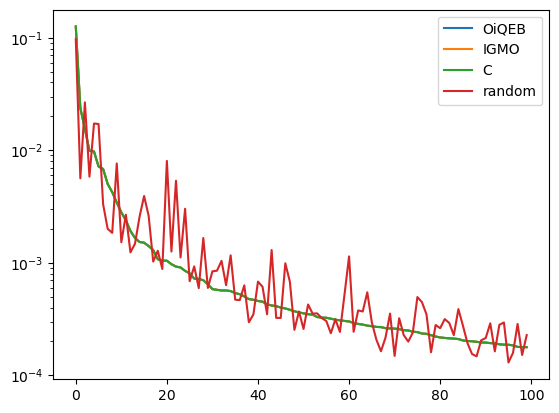

In [17]:
plt.plot(OiQEB_item_scores, label="OiQEB")
plt.plot(IGMO_items_scores, label="IGMO")
plt.plot(recalculated_C_scores, label="C")
plt.plot(random_scores, label="random")
plt.legend()
plt.yscale("log")
plt.show()

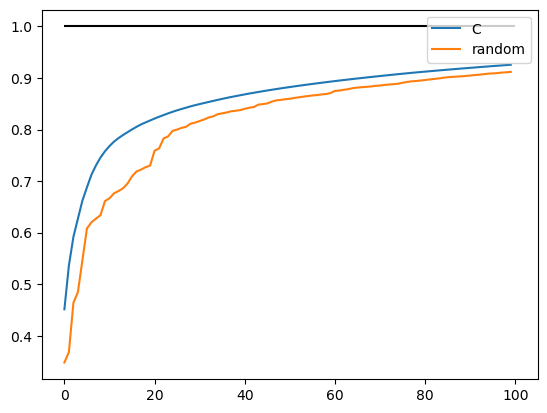

In [18]:
# plt.plot(np.cumsum(recalculated_IGMO_scores) / total_mse, label="greedy")
plt.plot(np.cumsum(recalculated_C_scores) / total_mse, label="C")
plt.plot(np.cumsum(random_scores) / total_mse, label="random")
plt.hlines(1, 0, n_items, color="black")
plt.legend()
# plt.yscale("log")
plt.show()

In [19]:
len(set(IGMO_items) & set(OiQEB_items))

100

In [20]:
len(set(IGMO_items) & set(C_items))

100

In [22]:
np.all(IGMO_items == OiQEB_items)

True

In [23]:
np.all(IGMO_items == C_items)

True

In [124]:
# validate scores

In [167]:
def veccos(a, b):
    return np.sum(a * b) / l2norm(a) / l2norm(b)